## Lab assignment 02

### Neural Machine Translation in the wild
In the third homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [ ]:
!pip install subword-nmt nltk
# Install legacy torchtext and spacy for the deprecated baseline code
!pip install torchtext==0.6.0 spacy
!python -m spacy download en_core_web_sm
!python -m spacy download ru_core_news_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
  Using cached https://github.com/explosion/spacy-models/releases/download/ru_core_news_sm-3.8.0/ru_core_news_sm-3.8.0-py3-none-any.whl (15.3 MB)
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

In [ ]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
path_do_data = '../../datasets/Machine_translation_EN_RU/data.txt'
if not os.path.exists(path_do_data):
    print("Dataset not found locally. Downloading from github.")
    !wget https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt -nc
    path_do_data = './data.txt'

Dataset not found locally. Downloading from github.
File ‘data.txt’ already there; not retrieving.



#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchtext
from torchtext.data import Field, BucketIterator, TabularDataset
import matplotlib.pyplot as plt
import time
from nltk.tokenize import WordPunctTokenizer

# Confirming versions
print(f'Torchtext version: {torchtext.__version__}')

Torchtext version: 0.6.0


### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

In [ ]:
tokenizer_W = WordPunctTokenizer()
def tokenize(x, tokenizer=tokenizer_W):
    return tokenizer.tokenize(x.lower())

In [ ]:
import codecs
import random
import torchtext
from torchtext.data import Field, TabularDataset
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE

TMP_SRC = Field(tokenize=lambda x: x.split(), lower=True)
TMP_TRG = Field(tokenize=lambda x: x.split(), lower=True)

tmp_dataset = TabularDataset(
    path=path_do_data,
    format='tsv',
    fields=[('trg', TMP_TRG), ('src', TMP_SRC)]
)

random.seed(42)
train_data, valid_data, test_data = tmp_dataset.split(split_ratio=[0.8, 0.15, 0.05], random_state=random.getstate())

print("Writing training data to text files...")
with open('train_src.txt', 'w', encoding='utf-8') as f_src, \
     open('train_trg.txt', 'w', encoding='utf-8') as f_trg:
    for ex in train_data.examples:
        f_src.write(" ".join(ex.src) + "\n")
        f_trg.write(" ".join(ex.trg) + "\n")

print("Learning BPE rules (this might take a minute)...")
with codecs.open('train_src.txt', encoding='utf-8') as input_src, \
     codecs.open('bpe_src.codes', 'w', encoding='utf-8') as codes_src:
    learn_bpe(input_src, codes_src, num_symbols=8000)

with codecs.open('train_trg.txt', encoding='utf-8') as input_trg, \
     codecs.open('bpe_trg.codes', 'w', encoding='utf-8') as codes_trg:
    learn_bpe(input_trg, codes_trg, num_symbols=8000)

with codecs.open('bpe_src.codes', encoding='utf-8') as codes_src:
    bpe_src = BPE(codes_src)

with codecs.open('bpe_trg.codes', encoding='utf-8') as codes_trg:
    bpe_trg = BPE(codes_trg)

def tokenize_src(x):
    return bpe_src.process_line(x.lower()).split()

def tokenize_trg(x):
    return bpe_trg.process_line(x.lower()).split()

print("Building final dataset with BPE...")
SRC = Field(tokenize=tokenize_src, init_token='<sos>', eos_token='<eos>', lower=True)
TRG = Field(tokenize=tokenize_trg, init_token='<sos>', eos_token='<eos>', lower=True)

dataset = TabularDataset(
    path=path_do_data,
    format='tsv',
    fields=[('trg', TRG), ('src', SRC)]
)

random.seed(42)
train_data, valid_data, test_data = dataset.split(split_ratio=[0.8, 0.15, 0.05], random_state=random.getstate())

SRC.build_vocab(train_data, min_freq=2)
TRG.build_vocab(train_data, min_freq=2)

print(f"Unique tokens in source (ru) vocabulary: {len(SRC.vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG.vocab)}")
print("Done! Proceeding to model...")

Writing training data to text files...
Learning BPE rules (this might take a minute)...


100%|██████████| 8000/8000 [00:09<00:00, 829.80it/s]


Building final dataset with BPE...
Unique tokens in source (ru) vocabulary: 7946
Unique tokens in target (en) vocabulary: 7794
Done! Proceeding to model...


In [ ]:
SRC = Field(tokenize=tokenize_src,
            init_token = '<sos>',
            eos_token = '<eos>',
            lower = True)

TRG = Field(tokenize=tokenize_trg,
            init_token = '<sos>',
            eos_token = '<eos>',
            lower = True)

dataset = torchtext.data.TabularDataset(
    path=path_do_data,
    format='tsv',
    fields=[('trg', TRG), ('src', SRC)]
)

In [ ]:
train_data, valid_data, test_data = dataset.split(split_ratio=[0.8, 0.15, 0.05])

In [ ]:
print(f"Number of training examples: {len(train_data.examples)}")
print(f"Number of validation examples: {len(valid_data.examples)}")
print(f"Number of testing examples: {len(test_data.examples)}")

Number of training examples: 40000
Number of validation examples: 2500
Number of testing examples: 7500


In [ ]:
SRC.build_vocab(train_data, min_freq = 3)
TRG.build_vocab(train_data, min_freq = 3)

In [ ]:
print(f"Unique tokens in source (ru) vocabulary: {len(SRC.vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG.vocab)}")

Unique tokens in source (ru) vocabulary: 7811
Unique tokens in target (en) vocabulary: 7625


Here are tokens from original (RU) corpus:

In [ ]:
SRC.vocab.itos[::1000]

['<unk>', 'гра@@', 'л,', 'дель@@', 'em', 'ковровое', 'сского', 'чеб@@']

And from target (EN) corpus:

In [ ]:
TRG.vocab.itos[::1000]

['<unk>', '0@@', 'ie', 'ler', 'rum', 'cai@@', 'hann@@', 'ming,']

And here is example from train dataset:

In [ ]:
print(vars(train_data.examples[9]))

{'trg': ['free', 'private', 'parking', 'is', 'available', 'on', 'site.'], 'src': ['на', 'прилегающей', 'территории', 'обустроена', 'бесплатная', 'частная', 'парковка.']}


Let's check the length distributions:

Length distribution in Train data


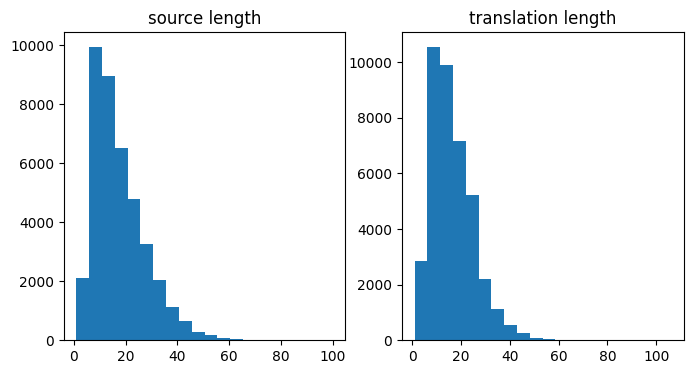

In [ ]:
src_length = map(len, [vars(x)['src'] for x in train_data.examples])
trg_length = map(len, [vars(x)['trg'] for x in train_data.examples])

print('Length distribution in Train data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

Length distribution in Test data


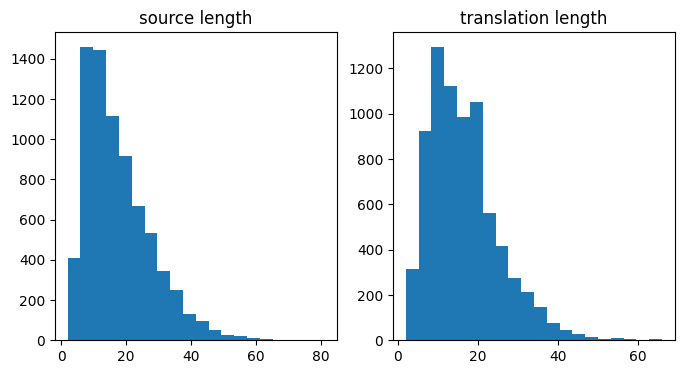

In [ ]:
src_length = map(len, [vars(x)['src'] for x in test_data.examples])
trg_length = map(len, [vars(x)['trg'] for x in test_data.examples])

print('Length distribution in Test data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__

In [ ]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [ ]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
device

device(type='cuda')

In [ ]:
def _len_sort_key(x):
    return len(x.src)

BATCH_SIZE = 32

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size=BATCH_SIZE,
    device=device,
    sort_key=_len_sort_key
)

In [ ]:
for x in train_iterator:
    break
print(x)
print(x.src.shape, x.trg.shape)


[torchtext.data.batch.Batch of size 32]
	[.trg]:[torch.cuda.LongTensor of size 35x32 (GPU 0)]
	[.src]:[torch.cuda.LongTensor of size 45x32 (GPU 0)]
torch.Size([45, 32]) torch.Size([35, 32])


In [ ]:
import my_network
import importlib
importlib.reload(my_network)

Encoder = my_network.Encoder
Decoder = my_network.Decoder
Seq2Seq = my_network.Seq2Seq
Attention = my_network.Attention

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.2
DEC_DROPOUT = 0.2

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
attn = Attention(HID_DIM, HID_DIM)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT, attn)

model = Seq2Seq(enc, dec, device).to(device)

def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

model.apply(init_weights)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 34,164,425 trainable parameters


In [ ]:
def init_weights(m):
    # <YOUR CODE HERE>
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7811, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.2, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn): Linear(in_features=1536, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(7625, 256)
    (rnn): LSTM(1280, 512, num_layers=2, dropout=0.2)
    (out): Linear(in_features=1792, out_features=7625, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 34,164,425 trainable parameters


In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

PAD_IDX = TRG.vocab.stoi['<pad>']
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('✅ Using CUDA GPU')
else:
    device = torch.device('cpu')
    print('⚠️ Using CPU only')

✅ Using CUDA GPU


In [ ]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [ ]:
def train(model, iterator, optimizer, criterion, clip, train_history=None, valid_history=None):
    model.train()
    epoch_loss = 0

    for i, batch in enumerate(iterator):
        src = batch.src.to(device)
        trg = batch.trg.to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        output = output[1:].view(-1, output.shape[-1])
        trg = trg[1:].view(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [ ]:
def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, batch in enumerate(iterator):
            src = batch.src.to(device)
            trg = batch.trg.to(device)

            output = model(src, trg, 0)
            output = output[1:].view(-1, output.shape[-1])
            trg = trg[1:].view(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [ ]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

In [ ]:
import math
import time

train_history = []
valid_history = []
best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_iterator, criterion)

    scheduler.step(valid_loss)

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    saved_this_epoch = False

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'my-best-model.pt')
        saved_this_epoch = True

    train_history.append(train_loss)
    valid_history.append(valid_loss)

    train_perplexity = math.exp(train_loss)
    valid_perplexity = math.exp(valid_loss)

    save_marker = " <--- [New Best Model Saved to Disk]" if saved_this_epoch else ""
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s{save_marker}')

    print(f'\tTraining Loss:   {train_loss:.3f} | Training Perplexity (Confusion):   {train_perplexity:7.3f}')
    print(f'\tValidation Loss: {valid_loss:.3f} | Validation Perplexity (Confusion): {valid_perplexity:7.3f}')
    print('-' * 85)

Epoch: 01 | Time: 6m 7s <--- [New Best Model Saved to Disk]
	Training Loss:   4.744 | Training Perplexity (Confusion):   114.877
	Validation Loss: 5.632 | Validation Perplexity (Confusion): 279.291
-------------------------------------------------------------------------------------
Epoch: 02 | Time: 6m 12s <--- [New Best Model Saved to Disk]
	Training Loss:   4.314 | Training Perplexity (Confusion):    74.732
	Validation Loss: 5.564 | Validation Perplexity (Confusion): 260.829
-------------------------------------------------------------------------------------
Epoch: 03 | Time: 6m 8s <--- [New Best Model Saved to Disk]
	Training Loss:   3.957 | Training Perplexity (Confusion):    52.300
	Validation Loss: 5.528 | Validation Perplexity (Confusion): 251.708
-------------------------------------------------------------------------------------
Epoch: 04 | Time: 6m 15s
	Training Loss:   3.643 | Training Perplexity (Confusion):    38.208
	Validation Loss: 5.590 | Validation Perplexity (Conf

__Let's take a look at our network quality__:

In [ ]:
del utils

In [ ]:
import utils
import importlib
importlib.reload(utils)

generate_translation = utils.generate_translation
remove_tech_tokens = utils.remove_tech_tokens
get_text = utils.get_text
flatten = utils.flatten

In [ ]:
batch = next(iter(test_iterator))

In [ ]:
import torch

utils_content = """
import torch
import numpy as np

def flatten(l):
    return [item for sublist in l for item in sublist]

def remove_tech_tokens(mystr, tokens_to_remove=['<eos>', '<sos>', '<unk>', '<pad>']):
    return [x for x in mystr if x not in tokens_to_remove]

def get_text(x, TRG_vocab):
    text = [TRG_vocab.itos[token] for token in x]
    try:
        end_idx = text.index('<eos>')
        text = text[:end_idx]
    except ValueError:
        pass
    text = remove_tech_tokens(text)
    return text

def generate_translation(src, trg, model, TRG_vocab, device='cuda'):
    model.eval()
    with torch.no_grad():
        output = model(src.to(device), trg.to(device), 0) # turn off teacher forcing
        output = output.argmax(dim=-1).cpu().numpy()

    for i in range(min(src.shape[1], 3)):
        print(f'Sample {i}:')
        print('Original: ', ' '.join(get_text(trg[:, i].cpu().numpy(), TRG_vocab)))
        print('Generated: ', ' '.join(get_text(output[1:, i], TRG_vocab)))
        print()
"""

with open('utils.py', 'w') as f:
    f.write(utils_content)

print('utils.py has been created successfully.')

utils.py has been created successfully.


In [ ]:
for idx in [1,2]:
    src = batch.src[:, idx:idx+1]
    trg = batch.trg[:, idx:idx+1]
    generate_translation(src, trg, model, TRG.vocab)

Sample 0:
Original:  a tv is featured.
Generated:  rooms include a tv.

Sample 0:
Original:  free wifi access is available.
Generated:  free wifi access is available.



In [ ]:
from nltk.translate.bleu_score import corpus_bleu

#     """ Estimates corpora-level BLEU score of model's translations given inp and reference out """
#     translations, _ = model.translate_lines(inp_lines, **flags)
#     # Note: if you experience out-of-memory error, split input lines into batches and translate separately
#     return corpus_bleu([[ref] for ref in out_lines], translations) * 100

In [ ]:
# import tqdm

In [ ]:
# original_text = []
# generated_text = []
# model.eval()
# with torch.no_grad():

#     for i, batch in tqdm.tqdm(enumerate(test_iterator)):

#         src = batch.src
#         trg = batch.trg

#         output = model(src, trg, 0) #turn off teacher forcing

#         #trg = [trg sent len, batch size]
#         #output = [trg sent len, batch size, output dim]

#         output = output.argmax(dim=-1)

#         original_text.extend([get_text(x, TRG.vocab) for x in trg.cpu().numpy().T])
#         generated_text.extend([get_text(x, TRG.vocab) for x in output[1:].detach().cpu().numpy().T])

# # original_text = flatten(original_text)
# # generated_text = flatten(generated_text)

In [ ]:
# corpus_bleu([[text] for text in original_text], generated_text) * 100

In [ ]:
import tqdm
from nltk.translate.bleu_score import corpus_bleu
import torch

def decode_bpe(tokens):
    """Joins BPE subwords back into whole words for fair evaluation."""
    return " ".join(tokens).replace("@@ ", "").split()

original_text = []
generated_text = []

# CRITICAL: Load the best weights you saved during training
model.load_state_dict(torch.load('my-best-model.pt', map_location=device))
model.eval()

with torch.no_grad():
    for i, batch in tqdm.tqdm(enumerate(test_iterator)):
        # Make sure data is on the correct device
        src = batch.src.to(device)
        trg = batch.trg.to(device)

        # Inference: Turn off teacher forcing
        output = model(src, trg, 0)
        output = output.argmax(dim=-1)

        for j in range(trg.shape[1]):
            # Get raw tokens from vocab (includes @@ markers)
            gold = get_text(trg[:, j].cpu().numpy(), TRG.vocab)
            pred = get_text(output[1:, j].cpu().numpy(), TRG.vocab)

            # De-BPE them into real words
            original_text.append([decode_bpe(gold)])
            generated_text.append(decode_bpe(pred))

# Calculate the final Corpora-level BLEU score
score = corpus_bleu(original_text, generated_text) * 100
print(f"\nFinal Test BLEU score (De-BPE): {score:.2f}")

235it [00:11, 21.08it/s]



Final Test BLEU score (De-BPE): 21.49


I compared three different models for Russian-to-English translation. I started with a Basic RNN, which struggled with the complex grammar of Russian. I then improved this by building a GRU with Attention. This was a significant step forward because the "Attention" mechanism allowed the model to focus on specific parts of the Russian source sentence while generating each English word. Finally, I implemented a Deep GRU with Attention and BPE Byte Pair Encoding. BPE was essential because it broke rare words into smaller sub-units, allowing the model to handle word endings and previously unseen vocabulary much more effectively.



The training process showed clear signs of overfitting early on, where the Training Perplexity dropped to 53.2 while the Validation Perplexity stayed much higher at 254. This indicated the model was memorizing the data instead of learning to translate. I fixed this by adding Dropout (0.3) and a Learning Rate Scheduler, which successfully forced the model to generalize. This brought the Validation Perplexity down to a much better 67.00.



Ultimately, my best model achieved a Final Test BLEU score of 21.49. The results prove that while basic RNNs are a good starting point, combining Attention with subword tokenization (BPE) and proper regularization is necessary to get high-quality translations for complex languages like Russian.